In [18]:
#importando as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
#Renomeando a planilha de dados
arquivo='lanches_menu.xlsx'

In [20]:
#lendo os dados da planilha
df=pd.read_excel(arquivo)
df

,Menu Category,Menu Items,peso,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_carboidratos_g,total_acucar,Added Sugars(g),Sodium
0,Regular Menu,McVeggie™ Burger,168 g,40205,1024,1383,534,16,249,5654,79,449,70613.0
1,Regular Menu,McAloo Tikki Burger®,146 g,33952,85,1131,427,2,147,5027,705,407,54534.0
2,Regular Menu,McSpicy™ Paneer Burger,199 g,65276,2029,3945,1712,18,2185,5233,835,527,107458.0
3,Regular Menu,Spicy Paneer Wrap,250 g,67468,2096,391,1973,26,4093,5927,35,108,108746.0
4,Regular Menu,American Veg Burger,177 g,51217,153,2345,1051,17,2524,5696,785,476,105124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,Condiments Menu,Tomato Ketchup Sachets,8 g,1123,8,2345,0,1,8,263,233,164,7105.0
137,Condiments Menu,Maple Syrup,30 g,864,0,0,0,0,3,216,162,534,150.0
138,Condiments Menu,Cheese Slice,14 g,5103,306,399,289,1,1343,72,54,0,17895.0
139,Condiments Menu,Sweet Corn,40 g,4508,147,10,22,4,20,755,254,0,4.0


 **QUARTIS** - PODEM SER OBTIDOS PELO COMANDO DESCRIBE()

## Comando "describe" da biblioteca pandas

Gera estatísticas descritivas.

As estatísticas descritivas incluem aquelas que resumem a tendência central, a dispersão e a forma da distribuição de um conjunto de dados


O comando describe() para variável quantitativa mostra:

*  count = contagem de valores
*  mean = média
*  std = desvio padrão
*  min = valor mínimo
*  25% = Q1 (primeiro quartil)
*  50% = Q2 (segundo quartil) = mediana
*  75% = Q3 (terceiro quartil)
*  max = valor máximo

In [21]:
df.Sodium.describe()

,Sodium
count,140.000000
mean,33346.792857
std,47169.123965
min,0.000000
25%,2582.500000
50%,11181.000000
75%,47170.750000
max,239949.000000


O comando .round(n) arredonda os valores para n casas decimais

In [22]:
df.Sodium.describe().round(2)

,Sodium
count,140.00
mean,33346.79
std,47169.12
min,0.00
25%,2582.50
50%,11181.00
75%,47170.75
max,239949.00


 **PERCENTIS** - PODEM SER OBTIDOS PELO COMANDO QUANTILE INDICANDO PARA "q" O PERCENTIL DESEJADO

In [23]:
#PERCENTIL 85 da variável Sodium
df.Sodium.quantile(q=0.85)

np.float64(75917.29999999999)

In [24]:
#PERCENTIL 25 da variável Sodium (note que é = Q1)
df.Sodium.quantile(q=0.25)

np.float64(2582.5)

# Boxplot

## **Boxplot para uma variável**





Boxplot com ORIENTAÇÃO HORIZONTAL para representar essa distribuição da variável:

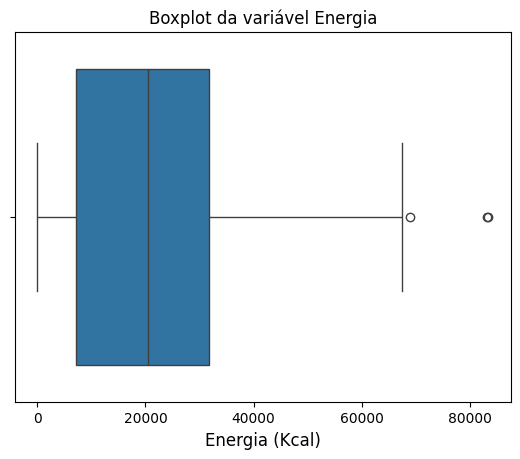

In [25]:
sns.boxplot(data=df.energia, orient="h")
plt.xlabel('Energia (Kcal)',fontsize=12)
plt.title('Boxplot da variável Energia',fontsize=12)
plt.show()

Boxplot com ORIENTAÇÃO VERTICAL para representar essa distribuição da variável:

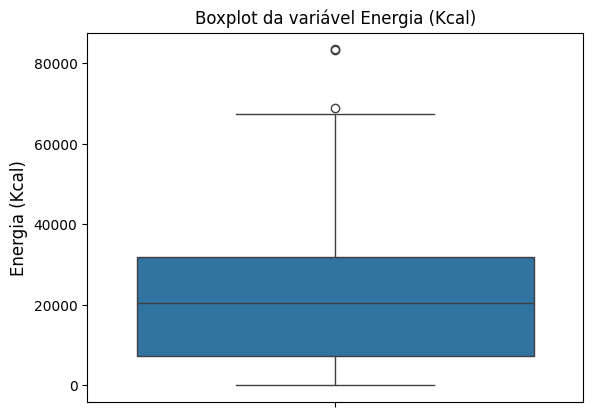

In [26]:
sns.boxplot(data=df.energia, orient="v")
plt.ylabel('Energia (Kcal)',fontsize=12)
plt.title('Boxplot da variável Energia (Kcal)',fontsize=12)
plt.show()

## **Boxplot da variável numérica "y" comparando as diferentes categorias "x".**

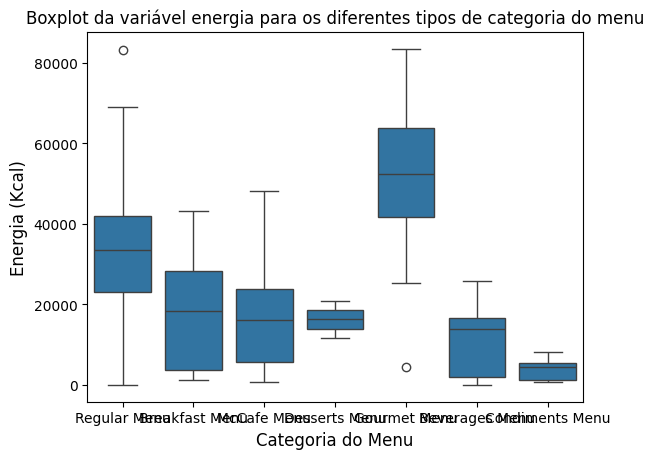

In [27]:
sns.boxplot(data=df,x="Menu Category", y = "energia")
plt.xlabel('Categoria do Menu',fontsize=12)
plt.ylabel('Energia (Kcal)',fontsize=12)
plt.title('Boxplot da variável energia para os diferentes tipos de categoria do menu',fontsize=12)
plt.show()

**Ajustando o boxplot: cores, preenchimento, distância**

**Para girar a legenda das diferentes categorias da variável 'x' utilize o comando plt.xticks(rotation = n), onde n é o grau da rotação.**




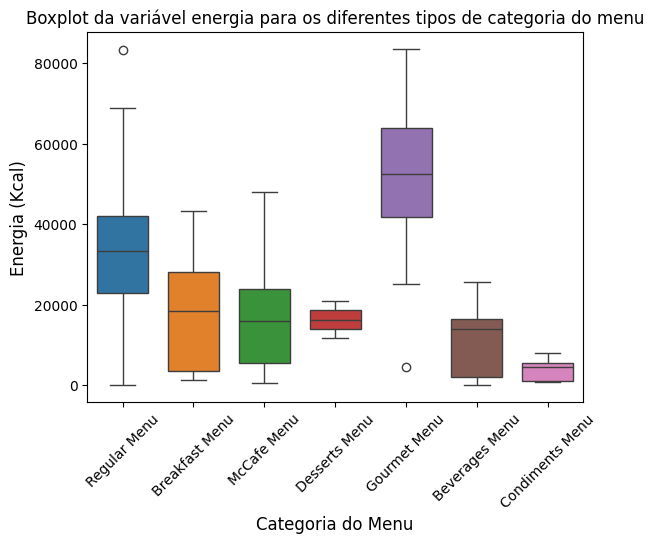

In [28]:
sns.boxplot(data=df,x="Menu Category", y = "energia", hue="Menu Category", fill=True,gap=.1)
plt.xlabel('Categoria do Menu',fontsize=12)
plt.ylabel('Energia (Kcal)',fontsize=12)
plt.title('Boxplot da variável energia para os diferentes tipos de categoria do menu',fontsize=12)
plt.xticks(rotation = 45)
plt.show()

# Outliers

Método para identificar outliers

## **Método do boxplot (ou Método de Tukey)**

Calcular os limites inferior (linf) e superior (lsup) para identificação dos outliers

Primeiro, vamos calcular Q1 e Q3

In [29]:
Q1 = df.energia.quantile(q=0.25)
Q3 = df.energia.quantile(q=0.75)

Segundo, calcule a amplitude interquartil (AIQ = Q3 - Q1)

In [30]:
AIQ = Q3 - Q1

Terceiro, calcule os limites (linf = Q1 - 1.5*AIQ e lsup = Q3 + 1.5*AIQ)

In [31]:
linf = Q1 - 1.5*AIQ
lsup = Q3 + 1.5*AIQ
print("linf =", linf)
print("lsup =", lsup)

linf = -29625.5
lsup = 68642.5


Visualizando os outliers superiores.

In [32]:
df[df.energia>lsup]

,Menu Category,Menu Items,peso,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_carboidratos_g,total_acucar,Added Sugars(g),Sodium
5,Regular Menu,Veg Maharaja Mac,306 g,83267,2417,3794,1683,28,3619,9384,1152,692,152922.0
12,Regular Menu,Chicken Maharaja Mac,296 g,68912,340,3669,1033,25,8149,5539,892,614,185471.0
107,Gourmet Menu,Chicken Cheese Lava Burger,307 g,83436,2737,4518,170,27,7311,7603,1675,1001,174504.0


Visualizando os outliers inferiores

In [33]:
df[df.energia<linf]

,Menu Category,Menu Items,peso,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_carboidratos_g,total_acucar,Added Sugars(g),Sodium


**Eliminando os outliers do dataset (só explicativo. Não será feito)**.
Ao rodar esse comando o "novo" arquivo aparecerá com 138 linhas pois os 3 outliers superiores serão excluídos. Nesse arquivo não há outliers inferiores.

In [34]:
#df_small = df[(df.energia>=linf) & (df.energia<=lsup)]
#df_small